function transformer

In [73]:
import pandas as pd 
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer


In [74]:
df=pd.read_csv('./train.csv',usecols=['Age','Fare','Survived'])

In [75]:
df['Age'].fillna(df['Age'].median(),inplace=True)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17436\1527141296.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(),inplace=True)


In [76]:
df

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500
...,...,...,...
886,0,27.0,13.0000
887,1,19.0,30.0000
888,0,28.0,23.4500
889,1,26.0,30.0000


In [77]:
X=df.iloc[:,1:3]
y=df.iloc[:,0]

In [78]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17436\1695891618.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'])


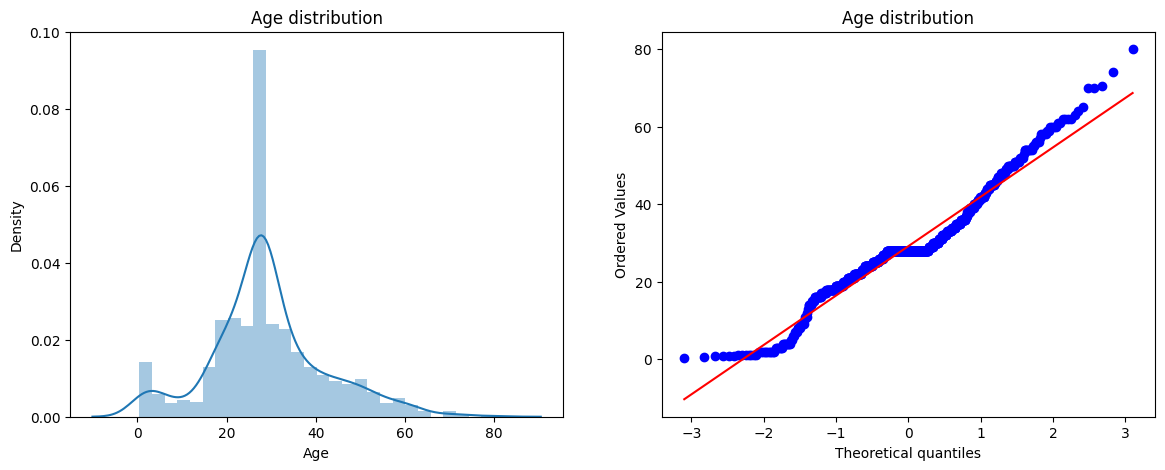

In [79]:
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
sns.distplot(X_train['Age'])
plt.title('Age distribution')
plt.subplot(1,2,2)
stats.probplot(X_train['Age'],dist='norm',plot=plt)
plt.title('Age distribution')
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17436\149036091.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Fare'])


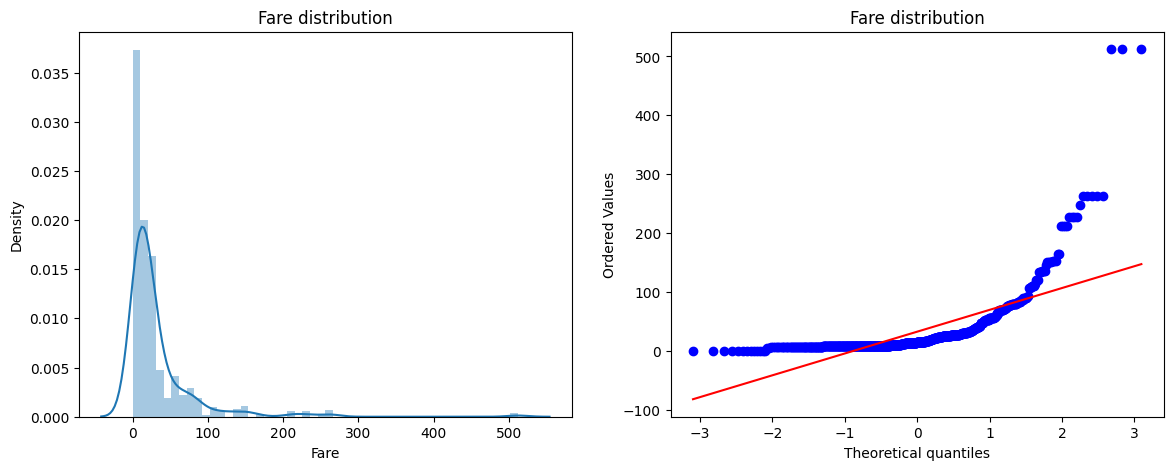

In [80]:
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
sns.distplot(X_train['Fare'])
plt.title('Fare distribution')
plt.subplot(1,2,2)
stats.probplot(X_train['Fare'],dist='norm',plot=plt)
plt.title('Fare distribution')
plt.show()

if dta is rightskewed use log transformation
if dta is leftskewed use exponential transformation


In [81]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()

In [82]:
clf.fit(X_train,y_train)
clf2.fit(X_train,y_train)
y_pred=clf.predict(X_test)
y_pred2=clf2.predict(X_test)    
print("Accuracy of LogisticRegression:",accuracy_score(y_test,y_pred))
print("Accuracy score of DecisionTreeClassifier:",accuracy_score(y_test,y_pred2))

Accuracy of LogisticRegression: 0.6480446927374302
Accuracy score of DecisionTreeClassifier: 0.659217877094972


In [83]:
trf=FunctionTransformer(func=np.log1p)
# here 1p is used to handle the zero values in the data as log(0) is undefined

In [84]:
X_train_transformed=trf.fit_transform(X_train)
X_test_transformed=trf.transform(X_test)

In [85]:
clf.fit(X_train_transformed,y_train)
clf2.fit(X_train_transformed,y_train)
y_pred=clf.predict(X_test_transformed)
y_pred2=clf2.predict(X_test_transformed)  
y_pred=clf.predict(X_test_transformed)
y_pred2=clf2.predict(X_test_transformed)    
print("Accuracy of LogisticRegression:",accuracy_score(y_test,y_pred))
print("Accuracy score of DecisionTreeClassifier:",accuracy_score(y_test,y_pred2)) 

Accuracy of LogisticRegression: 0.6759776536312849
Accuracy score of DecisionTreeClassifier: 0.659217877094972


In [88]:
X_transformed=trf.fit_transform(X)
clf=LogisticRegression()
clf2=DecisionTreeClassifier()
print("Cross validation score of LogisticRegression:",cross_val_score(clf,X_transformed,y,cv=5).mean())
print("Cross validation score of DecisionTreeClassifier:",cross_val_score(clf2,X_transformed,y,cv=5).mean())

Cross validation score of LogisticRegression: 0.6791287427029064
Cross validation score of DecisionTreeClassifier: 0.6532295524449188


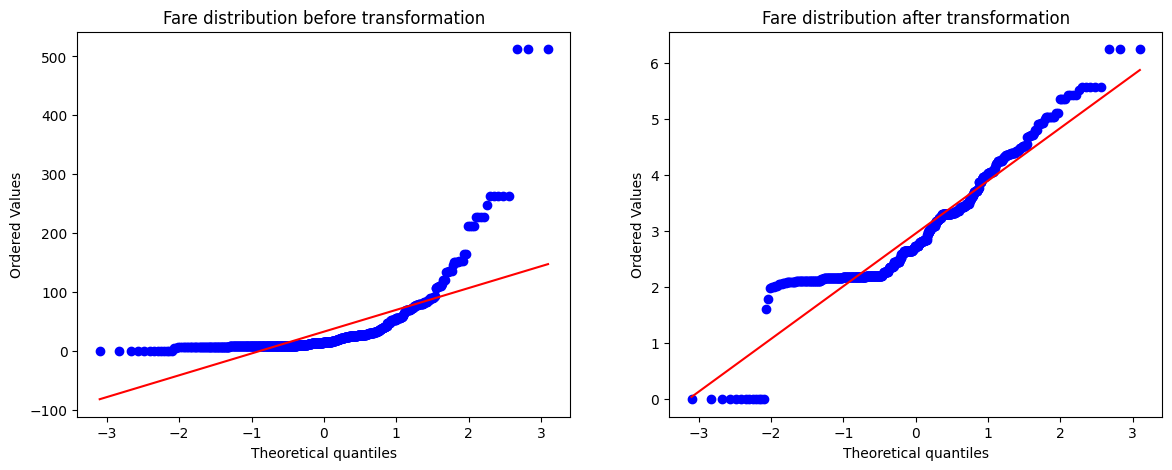

In [92]:
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
stats.probplot(X_train['Fare'],dist='norm',plot=plt)
plt.title('Fare distribution before transformation')
plt.subplot(1,2,2)
stats.probplot(X_train_transformed['Fare'],dist='norm',plot=plt)
plt.title('Fare distribution after transformation')
plt.show()

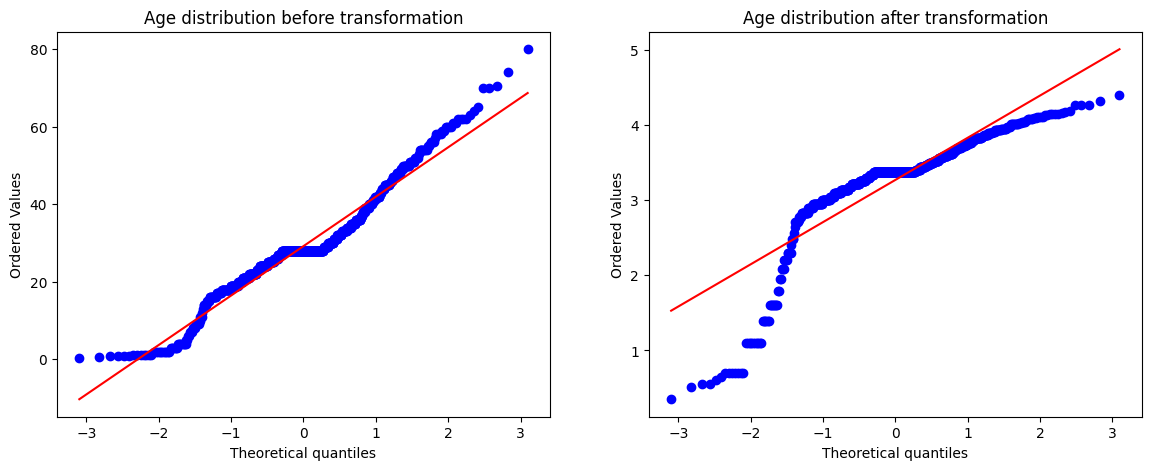

In [93]:
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
stats.probplot(X_train['Age'],dist='norm',plot=plt)
plt.title('Age distribution before transformation')
plt.subplot(1,2,2)
stats.probplot(X_train_transformed['Age'],dist='norm',plot=plt)
plt.title('Age distribution after transformation')
plt.show()

In [94]:

trf2=ColumnTransformer([('log',FunctionTransformer(func=np.log1p),['Fare'])],remainder='passthrough')
X_train_transformed2=trf2.fit_transform(X_train)
X_test_transformed2=trf2.transform(X_test)


In [95]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()
clf.fit(X_train_transformed2,y_train)
clf2.fit(X_train_transformed2,y_train)
y_pred=clf.predict(X_test_transformed2)
y_pred2=clf2.predict(X_test_transformed2)
print("Accuracy of LogisticRegression:",accuracy_score(y_test,y_pred))
print("Accuracy score of DecisionTreeClassifier:",accuracy_score(y_test,y_pred2))

Accuracy of LogisticRegression: 0.6759776536312849
Accuracy score of DecisionTreeClassifier: 0.664804469273743


In [97]:
X_transformed2=trf2.fit_transform(X)
clf=LogisticRegression()
clf2=DecisionTreeClassifier()
print("Cross validation score of LogisticRegression:",cross_val_score(clf,X_transformed2,y,cv=5).mean())
print("Cross validation score of DecisionTreeClassifier:",cross_val_score(clf2,X_transformed2,y,cv=5).mean())

Cross validation score of LogisticRegression: 0.6701399786579625
Cross validation score of DecisionTreeClassifier: 0.6498524888582009


In [98]:
def apply_transform(transform):
    X=df.iloc[:,1:3]
    y=df.iloc[:,0]
    trf=ColumnTransformer([('log',FunctionTransformer(func=transform),['Fare'])],remainder='passthrough')
    X_trans=trf.fit_transform(X)
    clf=LogisticRegression()
    clf2=DecisionTreeClassifier()
    print("Cross validation score of LogisticRegression:",cross_val_score(clf,X_trans,y,cv=5).mean())
    print("Cross validation score of DecisionTreeClassifier:",cross_val_score(clf2,X_trans,y,cv=5).mean())
    plt.figure(figsize=(14,5))
    plt.subplot(1,2,1)
    stats.probplot(X['Fare'],dist='norm',plot=plt)
    plt.title('Fare distribution before transformation')
    plt.subplot(1,2,2)
    stats.probplot(X['Fare'],dist='norm',plot=plt)
    plt.title('Fare distribution after transformation')
    plt.show()
    

Cross validation score of LogisticRegression: 0.6611637687527463
Cross validation score of DecisionTreeClassifier: 0.6453581068357291


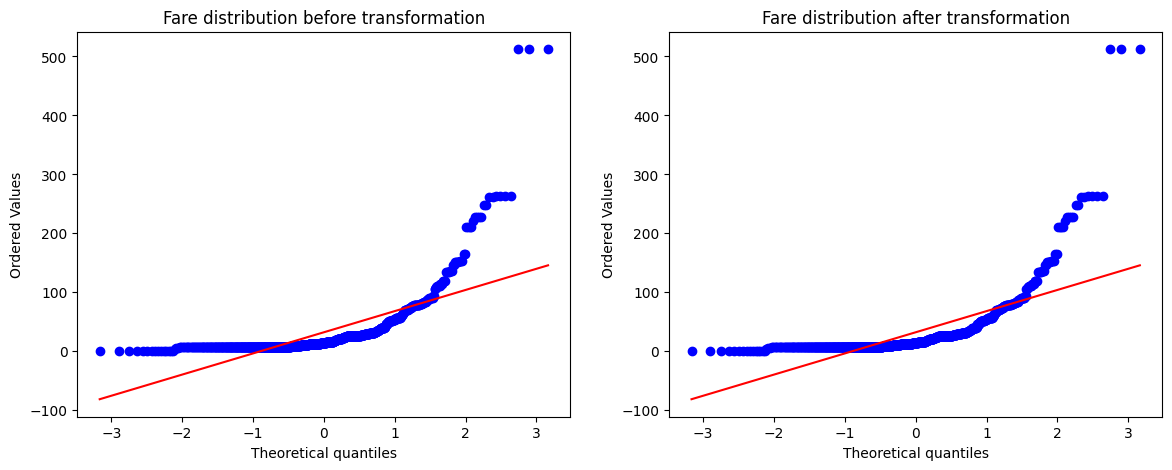

In [122]:
apply_transform(lambda x: (x**0.5-1)/0.5)